# Практическое задание: Классификация временных рядов (Time Series Classification)

**Цель обучения:**
Познакомиться с основными парадигмами классификации временных рядов (dictionary-based, shapelet-based, feature-based) и базовыми принципами работы с нейросетевыми архитектурами (1D-CNN) для временных рядов. Научиться применять продвинутые методы извлечения признаков и анализировать результаты их работы.

---

## **Задание №1: Теоретические вопросы**

**1. В чем принципиальная разница между SAX и Shapelets?**

SAX преобразует весь временной ряд в символьное представление (дискретизация амплитуд в буквы алфавита), работая глобально с рядом. Shapelets же ищут короткие подпоследовательности (фрагменты), которые максимально отличают один класс от другого, т.е. работают с локальными паттернами.

**2. Почему ROCKET быстрее классических shapelet-методов?**

ROCKET использует большое число случайных сверток (random kernels) фиксированной формы, а не перебирает все возможные подпоследовательности как shapelet-методы. Извлеченные признаки (max и proportion of positive values) затем подаются на линейный классификатор (Ridge), что делает обучение на порядки быстрее.

**3. Какие преимущества дает 1D-CNN по сравнению с ручным Feature Engineering?**

1D-CNN автоматически извлекает иерархию признаков разного масштаба через обучаемые фильтры, не требуя экспертного знания предметной области. Сеть может обнаруживать сложные нелинейные зависимости, которые трудно закодировать вручную.


# Часть 2: Практическая реализация и сравнение методов

## **Задание № 2:** Сравнить 3 подхода к классификации временных рядов на простом наборе данных `GunPoint` или любом другом стандартном датасете из библиотеки `sktime`.

**Необходимые библиотеки:**
- `sktime` (понадобится для ROCKET и BOSS/WEASEL)
- `catch22` или пакет `tsfel`
- `numpy`, `pandas`, `sklearn`, `matplotlib`
- `tensorflow` или `pytorch` (для 1D-CNN)

X_train shape: (147, 1, 251)
X_test shape: (64, 1, 251)


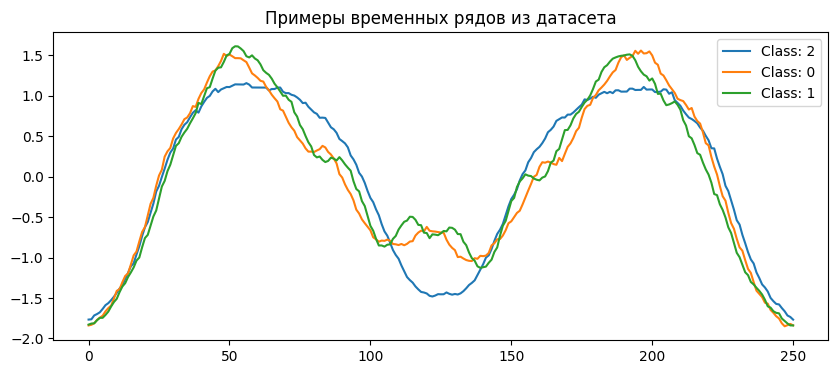

In [1]:
# Загрузка и подготовка данных
from sktime.datasets import load_arrow_head
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt

# Мы используем датасет ArrowHead (форма наконечников стрел) или любой другой из UCR
X, y = load_arrow_head(return_type="numpy3d")
# X имеет форму (Кол-во образцов, кол-во каналов=1, длина ряда)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

# Отрисовка пары примеров временных рядов разных классов
plt.figure(figsize=(10, 4))
for i in range(3):
    plt.plot(X_train[i, 0, :], label=f"Class: {y_train[i]}")
plt.title("Примеры временных рядов из датасета")
plt.legend()
plt.show()

### Задание 2.1: Классификация с помощью алгоритма ROCKET (Shapelets/Convolutions)

Используйте класс `RocketClassifier` из библиотеки `sktime`. Этот алгоритм генерирует случайные свертки для извлечения признаков и использует Ridge Regression для классификации.

**Задание:**
1. Подключите `RocketClassifier` из `sktime.classification.kernel_based`. Обучите его на `X_train`, `y_train`.
2. Предскажите классы для `X_test` и посчитайте `accuracy_score`. Замерьте время обучения.

In [2]:
from sktime.classification.kernel_based import RocketClassifier
import time

rocket = RocketClassifier(random_state=42)

start = time.time()
rocket.fit(X_train, y_train)
rocket_train_time = time.time() - start

rocket_preds = rocket.predict(X_test)
rocket_acc = accuracy_score(y_test, rocket_preds)

print(f'ROCKET Accuracy: {rocket_acc:.4f}')
print(f'Время обучения: {rocket_train_time:.2f} сек')
print()
print(classification_report(y_test, rocket_preds))


ROCKET Accuracy: 0.9375
Время обучения: 17.30 сек

              precision    recall  f1-score   support

           0       0.93      0.96      0.95        28
           1       0.94      0.94      0.94        17
           2       0.94      0.89      0.92        19

    accuracy                           0.94        64
   macro avg       0.94      0.93      0.94        64
weighted avg       0.94      0.94      0.94        64



### Задание № 2.2: Использование алгоритма на основе словарей (Dictionary-based: cBOSS / WEASEL)

Теперь протестируйте класс `BOSSEnsemble` или `ContractableBOSS` из библиотеки `sktime` (раздел `dictionary_based`).
Эти методы преобразуют временные ряды в дискретные слова (алфавит) с использованием скользящего окна (SFA), и оценивают частость.

**Задание:**
1. Подключите любую модель BOSS-семейства.
2. Проведите обучение и вычислите метрику `accuracy_score`. Сравните время обучения с ROCKET.

In [3]:
from sktime.classification.dictionary_based import ContractableBOSS

boss = ContractableBOSS(random_state=42)

start = time.time()
boss.fit(X_train, y_train)
boss_train_time = time.time() - start

boss_preds = boss.predict(X_test)
boss_acc = accuracy_score(y_test, boss_preds)

print(f'cBOSS Accuracy: {boss_acc:.4f}')
print(f'Время обучения: {boss_train_time:.2f} сек')
print()
print(classification_report(y_test, boss_preds))

print()
print(f'=== Сравнение времени обучения ===')
print(f'ROCKET: {rocket_train_time:.2f} сек')
print(f'cBOSS:  {boss_train_time:.2f} сек')


cBOSS Accuracy: 0.9531
Время обучения: 18.92 сек

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        28
           1       0.89      0.94      0.91        17
           2       0.94      0.89      0.92        19

    accuracy                           0.95        64
   macro avg       0.94      0.95      0.94        64
weighted avg       0.95      0.95      0.95        64


=== Сравнение времени обучения ===
ROCKET: 17.30 сек
cBOSS:  18.92 сек


### Задание №2.3: Глубокая архитектура для временных рядов (1D-CNN) (с помощью PyTorch)

Создайте простую свёрточную сеть с использованием 1D свёрток. Нейросети для 1D рядов похожи на 2D-сети (картинки), но срез окна проходит вдоль временной оси. Суть использования CNN-архитектур - извлечение сложных локальных и глобальных признаков (features) из формы временного ряда.

**Задание:**
1. Подготовьте данные для фреймворка (PyTorch). 
2. Напишите 2-3 слоя `Conv1D` + `ReLU` + `MaxPooling1D`, затем `Flatten` и выходной слой `Dense` c функцией Softmax.
3. Обучите модель в течение небольшого количества эпох, подсчитайте `accuracy` на тестовом наборе. Сравните с классическими методами (Rocket, BOSS).

In [4]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import LabelEncoder
import time
import matplotlib.pyplot as plt

In [5]:
# 1. Построение простой архитектуры 1D-CNN
class Simple1DCNN(nn.Module):
    def __init__(self, num_classes):
        super(Simple1DCNN, self).__init__()
        # Входной канал = 1 (так как у нас одномерный временной ряд)
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=32, kernel_size=3)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool1d(kernel_size=2)
        
        self.conv2 = nn.Conv1d(in_channels=32, out_channels=64, kernel_size=3)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool1d(kernel_size=2)
        
        self.flatten = nn.Flatten()
        
        # Вычисляем размер после сверток и пулинга (для ArrowHead с длиной 251)
        # После conv1: 251 - 3 + 1 = 249. pool1: 249 // 2 = 124
        # После conv2: 124 - 3 + 1 = 122. pool2: 122 // 2 = 61
        # Итого: 64 канала * 61 = 3904
        self.fc1 = nn.Linear(64 * 61, 128)
        self.relu3 = nn.ReLU()
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = self.flatten(x)
        x = self.relu3(self.fc1(x))
        x = self.fc2(x)
        return x

1D-CNN Accuracy: 0.9062
Время обучения: 4.46 сек

              precision    recall  f1-score   support

           0       0.89      0.89      0.89        28
           1       0.83      0.88      0.86        17
           2       1.00      0.95      0.97        19

    accuracy                           0.91        64
   macro avg       0.91      0.91      0.91        64
weighted avg       0.91      0.91      0.91        64



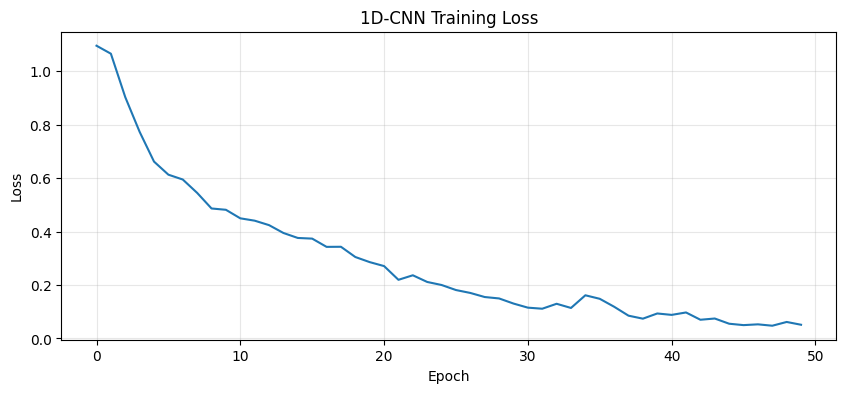


=== Итоговое сравнение ===
ROCKET:  acc=0.9375, time=17.30s
cBOSS:   acc=0.9531, time=18.92s
1D-CNN:  acc=0.9062, time=4.46s


In [6]:
# 2. Подготовка данных для PyTorch
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)
num_classes = len(le.classes_)

# X уже имеет форму (samples, channels, length) — подходит для Conv1d
X_train_t = torch.FloatTensor(X_train)
X_test_t = torch.FloatTensor(X_test)
y_train_t = torch.LongTensor(y_train_enc)
y_test_t = torch.LongTensor(y_test_enc)

train_ds = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)

# 3. Определяем размер fc слоя динамически
seq_len = X_train.shape[2]
# после conv1(k=3) -> pool(2) -> conv2(k=3) -> pool(2)
dummy = torch.zeros(1, 1, seq_len)
dummy_model = nn.Sequential(
    nn.Conv1d(1, 32, 3), nn.ReLU(), nn.MaxPool1d(2),
    nn.Conv1d(32, 64, 3), nn.ReLU(), nn.MaxPool1d(2),
    nn.Flatten()
)
fc_input_size = dummy_model(dummy).shape[1]

# обновляем модель с правильным fc размером
model = Simple1DCNN(num_classes)
model.fc = nn.Linear(fc_input_size, num_classes)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 4. Обучение
epochs = 50
losses = []

start = time.time()
for epoch in range(epochs):
    model.train()
    epoch_loss = 0
    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    losses.append(epoch_loss / len(train_loader))
cnn_train_time = time.time() - start

# 5. Оценка
model.eval()
with torch.no_grad():
    preds = model(X_test_t)
    cnn_preds = preds.argmax(dim=1).numpy()

cnn_acc = accuracy_score(y_test_enc, cnn_preds)

print(f'1D-CNN Accuracy: {cnn_acc:.4f}')
print(f'Время обучения: {cnn_train_time:.2f} сек')
print()
print(classification_report(y_test_enc, cnn_preds))

# 6. График потерь
plt.figure(figsize=(10, 4))
plt.plot(losses)
plt.title('1D-CNN Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(alpha=0.3)
plt.show()

# 7. Итоговое сравнение
print('\n=== Итоговое сравнение ===')
print(f'ROCKET:  acc={rocket_acc:.4f}, time={rocket_train_time:.2f}s')
print(f'cBOSS:   acc={boss_acc:.4f}, time={boss_train_time:.2f}s')
print(f'1D-CNN:  acc={cnn_acc:.4f}, time={cnn_train_time:.2f}s')
